# 1. Importing Libraries

In [1]:
#Common
import os
import keras
import pandas as pd
import numpy as np
import tensorflow as tf
from IPython.display import clear_output as cls

In [2]:
#Data Visualisation
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
#Data Loading
from keras.preprocessing.image import ImageDataGenerator as IDG
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img

In [4]:
#Model
import tensorflow_hub as hub
from keras.layers import Dense
from keras.models import Sequential, load_model

In [5]:
#Callbacks
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [6]:
#LR Scheduler
from tensorflow.keras.optimizers.schedules import PiecewiseConstantDecay as PWCD
from tensorflow.keras.optimizers import SGD

In [7]:
#Metrics
from keras.metrics import SparseCategoricalAccuracy, SparseTopKCategoricalAccuracy

# 2. Exploratory Data Analysis

In [8]:
#Specifying Data Path
path = 'Dataset'

#Class Name
class_names=sorted(os.listdir(path))
#class_names.remove("Poses.json") #We are considering only Yoga classes
n_classes = len(class_names)

#Display Results
print(f"Total Number of Classes: {n_classes}")
print(f"Classes : \n{class_names}")

Total Number of Classes: 47
Classes : 
['Adho Mukha Svanasana', 'Adho Mukha Vrksasana', 'Alanasana', 'Anjaneyasana', 'Ardha Chandrasana', 'Ardha Matsyendrasana', 'Ardha Navasana', 'Ardha Pincha Mayurasana', 'Ashta Chandrasana', 'Baddha Konasana', 'Bakasana', 'Balasana', 'Bitilasana', 'Camatkarasana', 'Dhanurasana', 'Eka Pada Rajakapotasana', 'Garudasana', 'Halasana', 'Hanumanasana', 'Malasana', 'Marjaryasana', 'Navasana', 'Padmasana', 'Parsva Virabhadrasana', 'Parsvottanasana', 'Paschimottanasana', 'Phalakasana', 'Pincha Mayurasana', 'Salamba Bhujangasana', 'Salamba Sarvangasana', 'Setu Bandha Sarvangasana', 'Sivasana', 'Supta Kapotasana', 'Trikonasana', 'Upavistha Konasana', 'Urdhva Dhanurasana', 'Urdhva Mukha Svsnssana', 'Ustrasana', 'Utkatasana', 'Uttanasana', 'Utthita Hasta Padangusthasana', 'Utthita Parsvakonasana', 'Vasisthasana', 'Virabhadrasana One', 'Virabhadrasana Three', 'Virabhadrasana Two', 'Vrksasana']


#### There are a total of 47 classes of Yoga Poses present in the dataset

### (a) Data Visualisation

In [9]:
#Calculating Class Distribution (Number of Files in each sub-directory)
class_dis = [len(os.listdir(path+f"/{name}")) for name in class_names]
print(class_dis)

[74, 65, 18, 71, 59, 96, 13, 54, 12, 81, 84, 79, 94, 62, 54, 53, 85, 71, 41, 73, 56, 18, 77, 14, 43, 62, 66, 43, 62, 73, 66, 20, 13, 23, 17, 74, 69, 96, 81, 71, 64, 69, 80, 64, 69, 61, 68]


In [10]:
min_num=max_num=class_dis[0]
for num in class_dis:
        if num < min_num:
            min_num = num
        if num > max_num:
            max_num = num
print("Minimum number:", min_num)
print("Maximum number:", max_num)

Minimum number: 12
Maximum number: 96


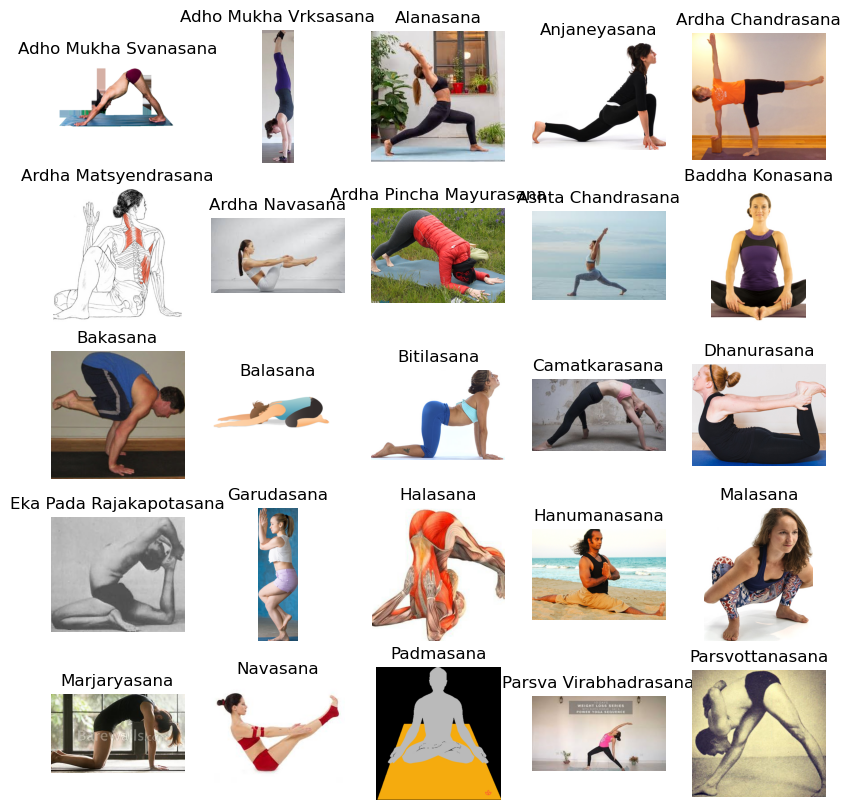

In [11]:
def plot_images(path):
    count = 1
    fig = plt.figure(figsize=(10, 10))
    for i in os.listdir(path):
        if count < 26:
            f_path = os.path.join(path,i)
            fig.add_subplot(5,5,count)
            plt.imshow(load_img(f"{os.path.join(f_path,os.listdir(f_path)[0])}"))
            plt.axis('off')
            plt.title(f'{i}')
            count+=1
    plt.show()
plot_images(path)

In [12]:
#Pie Plot
fig= px.pie(names=class_names, values=class_dis, title="Class Distribution")
fig.update_layout({'title':{'x':0.1}})
fig.show()

In [13]:
#Bar Plot
fig = px.bar(x=class_names, y=class_dis, color=class_names, title="Class Distribution")
fig.update_layout({'title':{'x':0.5}})
fig.show()

#### Classes are unequally distributed. The minimum number of images in a class are 12 whereas the maximum number of images in a class are 96. This can affect the model's performance.

In [14]:
import urllib.request

# Download the helper_functions.py file
url = "https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py"
filename = "helper_functions.py"
urllib.request.urlretrieve(url, filename)

# Import the helper functions
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir, pred_and_plot, make_confusion_matrix

In [15]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

In [16]:
walk_through_dir(path)

There are 47 directories and 0 images in 'Dataset'.
There are 0 directories and 74 images in 'Dataset\Adho Mukha Svanasana'.
There are 0 directories and 65 images in 'Dataset\Adho Mukha Vrksasana'.
There are 0 directories and 18 images in 'Dataset\Alanasana'.
There are 0 directories and 71 images in 'Dataset\Anjaneyasana'.
There are 0 directories and 59 images in 'Dataset\Ardha Chandrasana'.
There are 0 directories and 96 images in 'Dataset\Ardha Matsyendrasana'.
There are 0 directories and 13 images in 'Dataset\Ardha Navasana'.
There are 0 directories and 54 images in 'Dataset\Ardha Pincha Mayurasana'.
There are 0 directories and 12 images in 'Dataset\Ashta Chandrasana'.
There are 0 directories and 81 images in 'Dataset\Baddha Konasana'.
There are 0 directories and 84 images in 'Dataset\Bakasana'.
There are 0 directories and 79 images in 'Dataset\Balasana'.
There are 0 directories and 94 images in 'Dataset\Bitilasana'.
There are 0 directories and 62 images in 'Dataset\Camatkarasana'.


In [17]:
#Placing data in dataframe
from pathlib import Path

image_dir = Path(path)

# Get filepaths and labels
filepaths = list(image_dir.glob(r'**/*.JPG')) + list(image_dir.glob(r'**/*.jpg')) + list(image_dir.glob(r'**/*.png')) + list(image_dir.glob(r'**/*.png'))

labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
image_df = pd.concat([filepaths, labels], axis=1)

In [18]:
image_df

,Filepath,Label
0,Dataset\Adho Mukha Svanasana\File25.jpg,Adho Mukha Svanasana
1,Dataset\Ardha Navasana\File13.jpg,Ardha Navasana
2,Dataset\Baddha Konasana\File21.jpg,Baddha Konasana
3,Dataset\Baddha Konasana\File42.jpg,Baddha Konasana
4,Dataset\Baddha Konasana\File49.jpg,Baddha Konasana
...,...,...
4705,Dataset\Vrksasana\File62.png,Vrksasana
4706,Dataset\Vrksasana\File68.png,Vrksasana
4707,Dataset\Vrksasana\File7.png,Vrksasana
4708,Dataset\Vrksasana\File8.png,Vrksasana


In [19]:
# Specify the augmentation parameters
augmentation = IDG(
    rotation_range=10,      # Rotate images by 10 degrees
    width_shift_range=0.1,  # Shift images horizontally by 10% of the width
    height_shift_range=0.1, # Shift images vertically by 10% of the height
    shear_range=0.1,       # Apply shear transformation 
    zoom_range=0.1,         # Apply zoom transformation
    horizontal_flip=True,   # Flip images horizontally
    fill_mode='nearest'     # Fill newly created pixels near the edges with the nearest pixel value
)

In [20]:
# Augment the images in underrepresented classes
for class_name in class_names:
    class_dir = os.path.join(path, class_name)
    num_files = len(os.listdir(class_dir))
    if num_files < max_num:
        # Calculate the number of additional images to generate
        num_additional_images = max_num - num_files

        # Generate and save additional images
        image_files = os.listdir(class_dir)
        for i in range(num_additional_images):
            random_image_file = np.random.choice(image_files)
            image_path = os.path.join(class_dir, random_image_file)
            image = load_img(image_path)
            image = img_to_array(image)
            image = image.reshape((1,) + image.shape)
            augmented_images = augmentation.flow(image, batch_size=1, save_to_dir=class_dir, save_prefix='augmented_', save_format='jpeg')
            augmented_images.next()

In [21]:
#Checking Dataset post augmentation
#Specifying Data Path
path = 'Dataset'

#Class Name
class_names=sorted(os.listdir(path))
#class_names.remove("Poses.json") #We are considering only Yoga classes
n_classes = len(class_names)

#Display Results
print(f"Total Number of Classes: {n_classes}")
print(f"Classes : \n{class_names}")

Total Number of Classes: 47
Classes : 
['Adho Mukha Svanasana', 'Adho Mukha Vrksasana', 'Alanasana', 'Anjaneyasana', 'Ardha Chandrasana', 'Ardha Matsyendrasana', 'Ardha Navasana', 'Ardha Pincha Mayurasana', 'Ashta Chandrasana', 'Baddha Konasana', 'Bakasana', 'Balasana', 'Bitilasana', 'Camatkarasana', 'Dhanurasana', 'Eka Pada Rajakapotasana', 'Garudasana', 'Halasana', 'Hanumanasana', 'Malasana', 'Marjaryasana', 'Navasana', 'Padmasana', 'Parsva Virabhadrasana', 'Parsvottanasana', 'Paschimottanasana', 'Phalakasana', 'Pincha Mayurasana', 'Salamba Bhujangasana', 'Salamba Sarvangasana', 'Setu Bandha Sarvangasana', 'Sivasana', 'Supta Kapotasana', 'Trikonasana', 'Upavistha Konasana', 'Urdhva Dhanurasana', 'Urdhva Mukha Svsnssana', 'Ustrasana', 'Utkatasana', 'Uttanasana', 'Utthita Hasta Padangusthasana', 'Utthita Parsvakonasana', 'Vasisthasana', 'Virabhadrasana One', 'Virabhadrasana Three', 'Virabhadrasana Two', 'Vrksasana']


In [22]:
#Calculating Class Distribution (Number of Files in each sub-directory)
class_dis = [len(os.listdir(path+f"/{name}")) for name in class_names]
print(class_dis)

[96, 96, 96, 96, 96, 96, 94, 95, 95, 96, 96, 96, 96, 95, 96, 96, 96, 96, 95, 96, 96, 96, 96, 96, 96, 96, 96, 96, 95, 96, 96, 96, 95, 95, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96]


In [23]:
#Pie Plot
fig= px.pie(names=class_names, values=class_dis, title="Class Distribution")
fig.update_layout({'title':{'x':0.1}})
fig.show()

In [24]:
#Bar Plot
fig = px.bar(x=class_names, y=class_dis, color=class_names, title="Class Distribution")
fig.update_layout({'title':{'x':0.5}})
fig.show()

In [25]:
from keras.models import load_model
from keras.models import save_model
import numpy as np
import h5py
import cv2
import math
import random

In [26]:
# Plot Skeleton Keypoints
def plot_skeleton_kpts(im, kpts, radius=5, shape=(640, 640), confi=0.5, line_thick=2):
    pose_palette = np.array([[255, 128, 0], [255, 153, 51], [255, 178, 102], [230, 230, 0], [255, 153, 255],
                            [153, 204, 255], [255, 102, 255], [255, 51, 255], [102, 178, 255], [51, 153, 255],
                            [255, 153, 153], [255, 102, 102], [255, 51, 51], [153, 255, 153], [102, 255, 102],
                            [51, 255, 51], [0, 255, 0], [0, 0, 255], [255, 0, 0], [255, 255, 255]],
                            dtype=np.uint8)
    skeleton = [[16, 14], [14, 12], [17, 15], [15, 13], [12, 13], [6, 12], [7, 13], [6, 7], [6, 8], [7, 9],
                [8, 10], [9, 11], [2, 3], [1, 2], [1, 3], [2, 4], [3, 5], [4, 6], [5, 7]]
    
    limb_color = pose_palette[[9, 9, 9, 9, 7, 7, 7, 0, 0, 0, 0, 0, 16, 16, 16, 16, 16, 16, 16]]
    kpt_color = pose_palette[[16, 16, 16, 16, 16, 0, 0, 0, 0, 0, 0, 9, 9, 9, 9, 9, 9]]

    _, ndim = kpts.shape
    for i, k in enumerate(kpts):
        color_k = [int(x) for x in kpt_color[i]]
        x_coord, y_coord = k[0], k[1]
        if x_coord % shape[1] != 0 and y_coord % shape[0] != 0:
            if len(k) == 3:
                conf = k[2]
                if conf < confi:
                    continue
            cv2.circle(im, (int(x_coord), int(y_coord)), radius, color_k, -1, lineType=cv2.LINE_AA)

    ndim = kpts.shape[-1]
    for i, sk in enumerate(skeleton):
        pos1 = (int(kpts[(sk[0] - 1), 0]), int(kpts[(sk[0] - 1), 1]))
        pos2 = (int(kpts[(sk[1] - 1), 0]), int(kpts[(sk[1] - 1), 1]))
        if ndim == 3:
            conf1 = kpts[(sk[0] - 1), 2]
            conf2 = kpts[(sk[1] - 1), 2]
            if conf1 < confi or conf2 < confi:
                continue
        if pos1[0] % shape[1] == 0 or pos1[1] % shape[0] == 0 or pos1[0] < 0 or pos1[1] < 0:
            continue
        if pos2[0] % shape[1] == 0 or pos2[1] % shape[0] == 0 or pos2[0] < 0 or pos2[1] < 0:
            continue
        cv2.line(im, pos1, pos2, [int(x) for x in limb_color[i]], thickness=line_thick, lineType=cv2.LINE_AA)


# Normalize Keypoints
def norm_kpts(lm_list, torso_size_multiplier=2.5):
    max_distance = 0
    center_x = (lm_list[12][0] +       # right_hip
                lm_list[11][0])*0.5    # left_hip
    center_y = (lm_list[12][1] +       # right_hip
                lm_list[11][1])*0.5    # left_hip

    shoulders_x = (lm_list[6][0] +       # right_shoulder
                    lm_list[5][0])*0.5   # left_shoulder
    shoulders_y = (lm_list[6][1] +       # right_shoulder
                    lm_list[5][1])*0.5   # left_shoulder
    
    for lm in lm_list:
        distance = math.sqrt(
            (lm[0] - center_x)**2 + (lm[1] - center_y)**2)
        if(distance > max_distance):
            max_distance = distance
    torso_size = math.sqrt(
        (shoulders_x - center_x)**2 + (shoulders_y - center_y)**2)
    max_distance = max(
        torso_size*torso_size_multiplier, max_distance)

    pre_lm = list(np.array(
        [[(landmark[0]-center_x)/max_distance, (landmark[1]-center_y)/max_distance] for landmark in lm_list]
    ).flatten())
    
    return pre_lm


def plot_one_box(x, img, color=None, label=None, line_thickness=3):
    # Plots one bounding box on image img
    tl = line_thickness or round(0.002 * (img.shape[0] + img.shape[1]) / 2) + 1  # line/font thickness
    color = color or [random.randint(0, 255) for _ in range(3)]
    c1, c2 = (int(x[0]), int(x[1])), (int(x[2]), int(x[3]))
    cv2.rectangle(img, c1, c2, color, thickness=tl, lineType=cv2.LINE_AA)
    if label:
        tf = max(tl - 1, 1)  # font thickness
        t_size = cv2.getTextSize(label, 0, fontScale=tl / 3, thickness=tf)[0]
        c2 = c1[0] + t_size[0], c1[1] - t_size[1] - 3
        cv2.rectangle(img, c1, c2, color, -1, cv2.LINE_AA)  # filled
        cv2.putText(img, label, (c1[0], c1[1] - 2), 0, tl / 3, [225, 255, 255], thickness=tf, lineType=cv2.LINE_AA)


# Save and Load Keras Model with meta data
def load_model_ext(filepath):
    model = load_model(filepath, custom_objects=None, compile=False)
    f = h5py.File(filepath, mode='r')
    meta_data = None
    if 'my_meta_data' in f.attrs:
        meta_data = f.attrs.get('my_meta_data')
    f.close()
    return model, meta_data
   

def save_model_ext(model, filepath, overwrite=True, meta_data=None):
    save_model(model, filepath, overwrite)
    if meta_data is not None:
        f = h5py.File(filepath, mode='a')
        f.attrs['my_meta_data'] = meta_data
        f.close()

In [27]:
from ultralytics import YOLO
import pandas as pd
import cv2
import os
import glob
import argparse


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np


model = YOLO('yolov8n-pose.pt')
cap = cv2.VideoCapture(0)
poses = None

while True:
    success, img = cap.read()
    if not success:
        print('[INFO] Failed to Read...')
        break

    results = model.predict(img)
    for result in results:
        #print(result.keypoints.data)
        poses = result.keypoints.data

        #if poses is not None:
        for pose in poses:
            plot_skeleton_kpts(img, pose, radius=5, line_thick=2, confi=0.5)

    img = cv2.resize(img, (1600, 900))
    cv2.imshow('img', img)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [28]:
#Generate CSV File

from ultralytics import YOLO
import pandas as pd
import cv2
import os
import glob



path_data = 'Dataset'
path_to_save = 'data.csv'

col_names = [
    '0_X', '0_Y', '1_X', '1_Y', '2_X', '2_Y', '3_X', '3_Y', '4_X', '4_Y', '5_X', '5_Y', 
    '6_X', '6_Y', '7_X', '7_Y', '8_X', '8_Y', '9_X', '9_Y', '10_X', '10_Y', '11_X', '11_Y', 
    '12_X', '12_Y', '13_X', '13_Y', '14_X', '14_Y', '15_X', '15_Y', '16_X', '16_Y'
]

# YOLOv8 Pose Model
model = YOLO('yolov8n-pose.pt')

full_lm_list = []
target_list = []
class_names = sorted(os.listdir(path_data))

for class_name in class_names:
    path_to_class = os.path.join(path_data, class_name)
    img_list = glob.glob(path_to_class + '/*.jpg') + \
        glob.glob(path_to_class + '/*.jpeg') + \
        glob.glob(path_to_class + '/*.png')
    img_list = sorted(img_list)

    for img_path in img_list:
        img = cv2.imread(img_path)
        lm_list = []
        if img is None:
            print(
                f'[ERROR] Error in reading {img_path} -- Skipping.....\n[INFO] Taking next Image')
            continue
        else:
            results = model.predict(img)
            for result in results:
                poses = result.keypoints.data
                for pose in poses:
                    for pnt in pose:
                        x, y = pnt[:2] 
                        lm_list.append([int(x), int(y)])

        if len(lm_list) == 17:
            pre_lm = norm_kpts(lm_list)
            full_lm_list.append(pre_lm)
            target_list.append(class_name)

        print(f'{os.path.split(img_path)[1]} Landmarks added Successfully')
    print(f'[INFO] {class_name} Successfully Completed')
print('[INFO] Landmarks from Dataset Successfully Completed')

# to csv
data_x = pd.DataFrame(full_lm_list, columns=col_names)
data = data_x.assign(Pose_Class=target_list)
data.to_csv(path_to_save, encoding='utf-8', index=False)
print(f'[INFO] Successfully Saved Landmarks data into {path_to_save}')


0: 352x640 1 person, 515.6ms
Speed: 9.0ms preprocess, 515.6ms inference, 0.0ms postprocess per image at shape (1, 3, 352, 640)



File1.png Landmarks added Successfully


0: 480x640 2 persons, 575.0ms
Speed: 8.0ms preprocess, 575.0ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)



File10.png Landmarks added Successfully


0: 544x640 1 person, 648.7ms
Speed: 15.0ms preprocess, 648.7ms inference, 15.6ms postprocess per image at shape (1, 3, 544, 640)



...

augmented__0_9341.jpeg Landmarks added Successfully


0: 640x224 1 person, 390.6ms
Speed: 15.6ms preprocess, 390.6ms inference, 15.6ms postprocess per image at shape (1, 3, 640, 224)



augmented__0_9485.jpeg Landmarks added Successfully


0: 640x384 1 person, 562.5ms
Speed: 0.0ms preprocess, 562.5ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)


augmented__0_9798.jpeg Landmarks added Successfully
[INFO] Vrksasana Successfully Completed
[INFO] Landmarks from Dataset Successfully Completed
[INFO] Successfully Saved Landmarks data into data.csv


In [29]:
#train on Keras

from keras import layers, Sequential
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import keras

import pandas as pd
import os
import json
import argparse

[INFO] Loaded csv Dataset
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               17920     
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 47)                12079     
                                                                 
Total params: 161,327
Trainable params: 161,327
Non-trainable params: 0
_________________________________________________________________
Model Summary:  None
[INFO] Model Training Started ...
Epoch 1/200
161/166 [============================>.] - ETA: 0s - loss: 2.9801 - accuracy: 0.2259
Epoch 1: val_accuracy improved from -inf to 0.35552, saving model to runs\train0\weight-01-0.36.h5
166/166 [============================

Epoch 25/200
156/166 [===========================>..] - ETA: 0s - loss: 0.4582 - accuracy: 0.8530
Epoch 25: val_accuracy did not improve from 0.65809
166/166 [==============================] - 28s 171ms/step - loss: 0.4567 - accuracy: 0.8536 - val_loss: 1.4145 - val_accuracy: 0.6445
Epoch 26/200
156/166 [===========================>..] - ETA: 0s - loss: 0.4432 - accuracy: 0.8478
Epoch 26: val_accuracy did not improve from 0.65809
166/166 [==============================] - 27s 165ms/step - loss: 0.4479 - accuracy: 0.8460 - val_loss: 1.4549 - val_accuracy: 0.6490
Epoch 27/200
156/166 [===========================>..] - ETA: 0s - loss: 0.4050 - accuracy: 0.8722
Epoch 27: val_accuracy improved from 0.65809 to 0.66112, saving model to runs\train0\weight-27-0.66.h5
166/166 [==============================] - 26s 158ms/step - loss: 0.4126 - accuracy: 0.8680 - val_loss: 1.4270 - val_accuracy: 0.6611
Epoch 28/200
155/166 [===========================>..] - ETA: 0s - loss: 0.4011 - accuracy: 0.8613

Epoch 82/200
159/166 [===========================>..] - ETA: 0s - loss: 0.0588 - accuracy: 0.9847
Epoch 82: val_accuracy did not improve from 0.70348
166/166 [==============================] - 28s 172ms/step - loss: 0.0586 - accuracy: 0.9849 - val_loss: 2.3109 - val_accuracy: 0.7005
Epoch 83/200
164/166 [============================>.] - ETA: 0s - loss: 0.0827 - accuracy: 0.9756
Epoch 83: val_accuracy did not improve from 0.70348
166/166 [==============================] - 29s 176ms/step - loss: 0.0822 - accuracy: 0.9758 - val_loss: 2.3084 - val_accuracy: 0.6657
Epoch 84/200
158/166 [===========================>..] - ETA: 0s - loss: 0.1039 - accuracy: 0.9672
Epoch 84: val_accuracy did not improve from 0.70348
166/166 [==============================] - 29s 173ms/step - loss: 0.1035 - accuracy: 0.9675 - val_loss: 2.3935 - val_accuracy: 0.6838
Epoch 85/200
160/166 [===========================>..] - ETA: 0s - loss: 0.1063 - accuracy: 0.9672
Epoch 85: val_accuracy did not improve from 0.7034

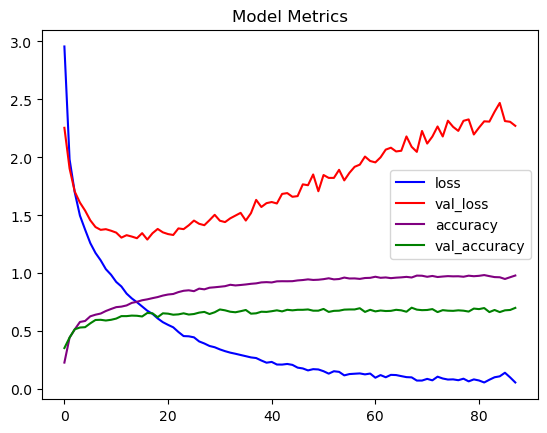

In [30]:
path_csv = "data.csv"
#path_to_save = "model/model.h5" #Path to save .h5 model

# Load .csv Data
df = pd.read_csv(path_csv)
class_list = df['Pose_Class'].unique()
class_list = sorted(class_list)
labels_string = json.dumps(class_list)
class_number = len(class_list)

# Create training and validation splits
x = df.copy()
y = x.pop('Pose_Class')
y, _ = y.factorize()
x = x.astype('float64')
y = keras.utils.to_categorical(y)

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=0)

print('[INFO] Loaded csv Dataset')

model = Sequential([
    layers.Dense(512, activation='relu', input_shape=[x_train.shape[1]]),
    layers.Dense(256, activation='relu'),
    layers.Dense(class_number, activation="softmax") #softmax is used to return probability
])

#Above model is overfitting We can reduce overfitting as follows:
#1. Reduce network's capacity by removing layers or reducing no of elements in hidden layers
#2. Apply regularization, ie adding cost to loss function for large weights
#3. Use Dropout layers, i.e. randomly remove certain features by setting them to 0

# Model Summary
print('Model Summary: ', model.summary())

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Save Model Dir
os.makedirs('runs', exist_ok=True)
c = 0
while True:
    path_save = os.path.join('runs', f'train{c}')
    if not os.path.exists(path_save):
        os.makedirs(path_save, exist_ok=True)
        break
    else:
        c += 1
        continue
        
# Add a checkpoint callback to store the checkpoint that has the highest
# validation accuracy.
ckpt_path = os.path.join(path_save, "weight-{epoch:02d}-{val_accuracy:.2f}.h5")
checkpoint = keras.callbacks.ModelCheckpoint(ckpt_path,
                                             monitor='val_accuracy',
                                             verbose=1,
                                             save_best_only=True,
                                             mode='max')
earlystopping = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=20)

# Start training
print('[INFO] Model Training Started ...')

history = model.fit(x_train, y_train,
                    epochs=200,
                    batch_size=16,
                    validation_data=(x_test, y_test),
                    callbacks=[checkpoint, earlystopping])

print('[INFO] Model Training Completed')
save_model_ext(model, os.path.join(path_save, 'model.h5'), meta_data=labels_string)
print(f'[INFO] Model Successfully Saved \033[1m model.h5 \033[0;0m in {path_save}')

# Plot History
metric_loss = history.history['loss']
metric_val_loss = history.history['val_loss']
metric_accuracy = history.history['accuracy']
metric_val_accuracy = history.history['val_accuracy']

# Construct a range object which will be used as x-axis (horizontal plane) of the graph.
epochs = range(len(metric_loss))

# Plot the Graph.
plt.plot(epochs, metric_loss, 'blue', label=metric_loss)
plt.plot(epochs, metric_val_loss, 'red', label=metric_val_loss)
plt.plot(epochs, metric_accuracy, 'purple', label=metric_accuracy)
plt.plot(epochs, metric_val_accuracy, 'green', label=metric_val_accuracy)

# Add title to the plot.
plt.title(str('Model Metrics'))

# Add legend to the plot.
plt.legend(['loss', 'val_loss', 'accuracy', 'val_accuracy'])

# If the plot already exist, remove
plt.savefig(os.path.join(path_save, 'metrics.png'), bbox_inches='tight')
print(f'[INFO] Successfully Saved \033[1m metrics.png \033[0;0m in {path_save}')

[INFO] Loaded csv Dataset
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 512)               17920     
                                                                 
 dense_6 (Dense)             (None, 47)                24111     
                                                                 
Total params: 42,031
Trainable params: 42,031
Non-trainable params: 0
_________________________________________________________________
Model Summary:  None
[INFO] Model Training Started ...
Epoch 1/200
158/166 [===========================>..] - ETA: 0s - loss: 3.2611 - accuracy: 0.1752
Epoch 1: val_accuracy improved from -inf to 0.31316, saving model to runs1\train0\weight-01-0.31.h5
166/166 [==============================] - 97s 298ms/step - loss: 3.2361 - accuracy: 0.1793 - val_loss: 2.6536 - val_accuracy: 0.3132
Epoch 2/200
159/166 [=============

Epoch 25/200
158/166 [===========================>..] - ETA: 0s - loss: 0.8290 - accuracy: 0.7480
Epoch 25: val_accuracy did not improve from 0.63086
166/166 [==============================] - 39s 236ms/step - loss: 0.8284 - accuracy: 0.7491 - val_loss: 1.3127 - val_accuracy: 0.6278
Epoch 26/200
158/166 [===========================>..] - ETA: 0s - loss: 0.8172 - accuracy: 0.7551
Epoch 26: val_accuracy improved from 0.63086 to 0.64750, saving model to runs1\train0\weight-26-0.65.h5
166/166 [==============================] - 37s 225ms/step - loss: 0.8139 - accuracy: 0.7560 - val_loss: 1.3114 - val_accuracy: 0.6475
Epoch 27/200
160/166 [===========================>..] - ETA: 0s - loss: 0.7900 - accuracy: 0.7664
Epoch 27: val_accuracy did not improve from 0.64750
166/166 [==============================] - 44s 265ms/step - loss: 0.7903 - accuracy: 0.7643 - val_loss: 1.3122 - val_accuracy: 0.6309
Epoch 28/200
164/166 [============================>.] - ETA: 0s - loss: 0.7743 - accuracy: 0.765

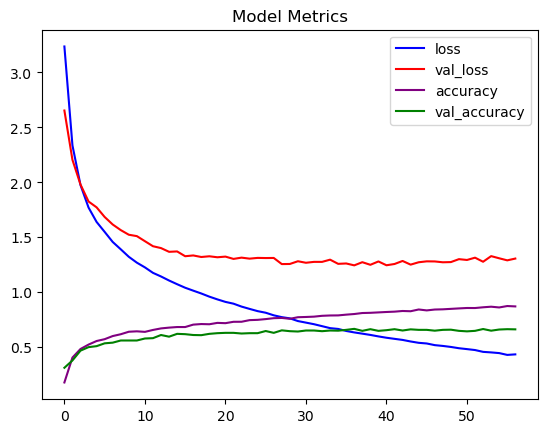

In [34]:
#1. Reduce network's capacity by removing layers or reducing no of elements in hidden layers

path_csv = "data.csv"
#path_to_save = "model/model.h5" #Path to save .h5 model

# Load .csv Data
df = pd.read_csv(path_csv)
class_list = df['Pose_Class'].unique()
class_list = sorted(class_list)
labels_string = json.dumps(class_list)
class_number = len(class_list)

# Create training and validation splits
x = df.copy()
y = x.pop('Pose_Class')
y, _ = y.factorize()
x = x.astype('float64')
y = keras.utils.to_categorical(y)

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=0)

print('[INFO] Loaded csv Dataset')

model1 = Sequential([
    layers.Dense(512, activation='relu', input_shape=[x_train.shape[1]]),
    #layers.Dense(256, activation='relu'),
    layers.Dense(class_number, activation="softmax") #softmax is used to return probability
])

# Model Summary
print('Model Summary: ', model1.summary())

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Save Model Dir
os.makedirs('runs1', exist_ok=True)
c = 0
while True:
    path_save = os.path.join('runs1', f'train{c}')
    if not os.path.exists(path_save):
        os.makedirs(path_save, exist_ok=True)
        break
    else:
        c += 1
        continue
        
# Add a checkpoint callback to store the checkpoint that has the highest
# validation accuracy.
ckpt_path = os.path.join(path_save, "weight-{epoch:02d}-{val_accuracy:.2f}.h5")
checkpoint = keras.callbacks.ModelCheckpoint(ckpt_path,
                                             monitor='val_accuracy',
                                             verbose=1,
                                             save_best_only=True,
                                             mode='max')
earlystopping = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=20)

# Start training
print('[INFO] Model Training Started ...')

history = model1.fit(x_train, y_train,
                    epochs=200,
                    batch_size=16,
                    validation_data=(x_test, y_test),
                    callbacks=[checkpoint, earlystopping])

print('[INFO] Model Training Completed')
save_model_ext(model1, os.path.join(path_save, 'model.h5'), meta_data=labels_string)
print(f'[INFO] Model Successfully Saved \033[1m model.h5 \033[0;0m in {path_save}')

# Plot History
metric_loss = history.history['loss']
metric_val_loss = history.history['val_loss']
metric_accuracy = history.history['accuracy']
metric_val_accuracy = history.history['val_accuracy']

# Construct a range object which will be used as x-axis (horizontal plane) of the graph.
epochs = range(len(metric_loss))

# Plot the Graph.
plt.plot(epochs, metric_loss, 'blue', label=metric_loss)
plt.plot(epochs, metric_val_loss, 'red', label=metric_val_loss)
plt.plot(epochs, metric_accuracy, 'purple', label=metric_accuracy)
plt.plot(epochs, metric_val_accuracy, 'green', label=metric_val_accuracy)

# Add title to the plot.
plt.title(str('Model Metrics'))

# Add legend to the plot.
plt.legend(['loss', 'val_loss', 'accuracy', 'val_accuracy'])

# If the plot already exist, remove
plt.savefig(os.path.join(path_save, 'metrics.png'), bbox_inches='tight')
print(f'[INFO] Successfully Saved \033[1m metrics.png \033[0;0m in {path_save}')

[INFO] Loaded csv Dataset
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 64)                2240      
                                                                 
 dense_8 (Dense)             (None, 47)                3055      
                                                                 
Total params: 5,295
Trainable params: 5,295
Non-trainable params: 0
_________________________________________________________________
Model Summary:  None
[INFO] Model Training Started ...
Epoch 1/200
164/166 [============================>.] - ETA: 0s - loss: 3.6195 - accuracy: 0.0983
Epoch 1: val_accuracy improved from -inf to 0.12708, saving model to runs2\train1\weight-01-0.13.h5
166/166 [==============================] - 98s 303ms/step - loss: 3.6170 - accuracy: 0.0991 - val_loss: 3.3376 - val_accuracy: 0.1271
Epoch 2/200
163/166 [===============

Epoch 24/200
155/166 [===========================>..] - ETA: 0s - loss: 1.4125 - accuracy: 0.6181
Epoch 24: val_accuracy did not improve from 0.54917
166/166 [==============================] - 45s 270ms/step - loss: 1.4123 - accuracy: 0.6201 - val_loss: 1.6365 - val_accuracy: 0.5431
Epoch 25/200
165/166 [============================>.] - ETA: 0s - loss: 1.3979 - accuracy: 0.6223
Epoch 25: val_accuracy improved from 0.54917 to 0.55371, saving model to runs2\train1\weight-25-0.55.h5
166/166 [==============================] - 39s 238ms/step - loss: 1.3986 - accuracy: 0.6224 - val_loss: 1.6206 - val_accuracy: 0.5537
Epoch 26/200
161/166 [============================>.] - ETA: 0s - loss: 1.3753 - accuracy: 0.6231
Epoch 26: val_accuracy did not improve from 0.55371
166/166 [==============================] - 38s 228ms/step - loss: 1.3769 - accuracy: 0.6228 - val_loss: 1.6237 - val_accuracy: 0.5522
Epoch 27/200
165/166 [============================>.] - ETA: 0s - loss: 1.3620 - accuracy: 0.619

156/166 [===========================>..] - ETA: 0s - loss: 1.0811 - accuracy: 0.6835
Epoch 51: val_accuracy improved from 0.59909 to 0.60061, saving model to runs2\train1\weight-51-0.60.h5
166/166 [==============================] - 26s 159ms/step - loss: 1.0922 - accuracy: 0.6810 - val_loss: 1.4283 - val_accuracy: 0.6006
Epoch 52/200
158/166 [===========================>..] - ETA: 0s - loss: 1.0864 - accuracy: 0.6808
Epoch 52: val_accuracy improved from 0.60061 to 0.60212, saving model to runs2\train1\weight-52-0.60.h5
166/166 [==============================] - 26s 158ms/step - loss: 1.0818 - accuracy: 0.6818 - val_loss: 1.4213 - val_accuracy: 0.6021
Epoch 53/200
163/166 [============================>.] - ETA: 0s - loss: 1.0769 - accuracy: 0.6879
Epoch 53: val_accuracy improved from 0.60212 to 0.60363, saving model to runs2\train1\weight-53-0.60.h5
166/166 [==============================] - 26s 158ms/step - loss: 1.0766 - accuracy: 0.6875 - val_loss: 1.4180 - val_accuracy: 0.6036
Epoch

157/166 [===========================>..] - ETA: 0s - loss: 0.7895 - accuracy: 0.7596
Epoch 106: val_accuracy did not improve from 0.64448
166/166 [==============================] - 34s 208ms/step - loss: 0.7882 - accuracy: 0.7605 - val_loss: 1.3600 - val_accuracy: 0.6384
Epoch 107/200
156/166 [===========================>..] - ETA: 0s - loss: 0.7771 - accuracy: 0.7604
Epoch 107: val_accuracy did not improve from 0.64448
166/166 [==============================] - 42s 256ms/step - loss: 0.7817 - accuracy: 0.7613 - val_loss: 1.3557 - val_accuracy: 0.6369
Epoch 108/200
158/166 [===========================>..] - ETA: 0s - loss: 0.7783 - accuracy: 0.7599
Epoch 108: val_accuracy did not improve from 0.64448
166/166 [==============================] - 43s 259ms/step - loss: 0.7784 - accuracy: 0.7613 - val_loss: 1.3664 - val_accuracy: 0.6399
Epoch 109/200
157/166 [===========================>..] - ETA: 0s - loss: 0.7670 - accuracy: 0.7663
Epoch 109: val_accuracy did not improve from 0.64448
166/

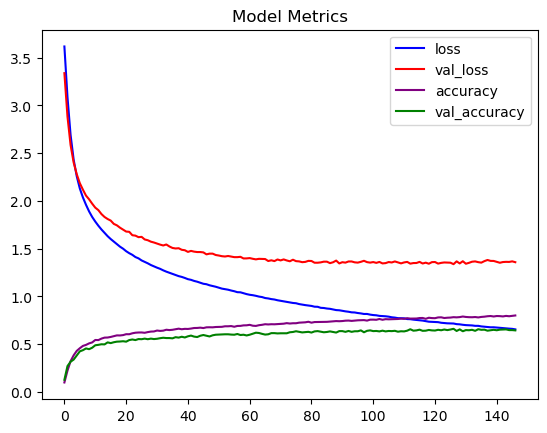

In [35]:
#1. Reduce network's capacity by removing layers or reducing no of elements in hidden layers

path_csv = "data.csv"
#path_to_save = "model/model.h5" #Path to save .h5 model

# Load .csv Data
df = pd.read_csv(path_csv)
class_list = df['Pose_Class'].unique()
class_list = sorted(class_list)
labels_string = json.dumps(class_list)
class_number = len(class_list)

# Create training and validation splits
x = df.copy()
y = x.pop('Pose_Class')
y, _ = y.factorize()
x = x.astype('float64')
y = keras.utils.to_categorical(y)

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=0)

print('[INFO] Loaded csv Dataset')

model2 = Sequential([
    layers.Dense(64, activation='relu', input_shape=[x_train.shape[1]]),
    #layers.Dense(256, activation='relu'),
    layers.Dense(class_number, activation="softmax") #softmax is used to return probability
])

# Model Summary
print('Model Summary: ', model2.summary())

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Save Model Dir
os.makedirs('runs1', exist_ok=True)
c = 0
while True:
    path_save = os.path.join('runs2', f'train{c}')
    if not os.path.exists(path_save):
        os.makedirs(path_save, exist_ok=True)
        break
    else:
        c += 1
        continue
        
# Add a checkpoint callback to store the checkpoint that has the highest
# validation accuracy.
ckpt_path = os.path.join(path_save, "weight-{epoch:02d}-{val_accuracy:.2f}.h5")
checkpoint = keras.callbacks.ModelCheckpoint(ckpt_path,
                                             monitor='val_accuracy',
                                             verbose=1,
                                             save_best_only=True,
                                             mode='max')
earlystopping = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=20)

# Start training
print('[INFO] Model Training Started ...')

history = model2.fit(x_train, y_train,
                    epochs=200,
                    batch_size=16,
                    validation_data=(x_test, y_test),
                    callbacks=[checkpoint, earlystopping])

print('[INFO] Model Training Completed')
save_model_ext(model2, os.path.join(path_save, 'model.h5'), meta_data=labels_string)
print(f'[INFO] Model Successfully Saved \033[1m model.h5 \033[0;0m in {path_save}')

# Plot History
metric_loss = history.history['loss']
metric_val_loss = history.history['val_loss']
metric_accuracy = history.history['accuracy']
metric_val_accuracy = history.history['val_accuracy']

# Construct a range object which will be used as x-axis (horizontal plane) of the graph.
epochs = range(len(metric_loss))

# Plot the Graph.
plt.plot(epochs, metric_loss, 'blue', label=metric_loss)
plt.plot(epochs, metric_val_loss, 'red', label=metric_val_loss)
plt.plot(epochs, metric_accuracy, 'purple', label=metric_accuracy)
plt.plot(epochs, metric_val_accuracy, 'green', label=metric_val_accuracy)

# Add title to the plot.
plt.title(str('Model Metrics'))

# Add legend to the plot.
plt.legend(['loss', 'val_loss', 'accuracy', 'val_accuracy'])

# If the plot already exist, remove
plt.savefig(os.path.join(path_save, 'metrics.png'), bbox_inches='tight')
print(f'[INFO] Successfully Saved \033[1m metrics.png \033[0;0m in {path_save}')

In [36]:
model.evaluate(x_train, y_train)

83/83 [==============================] - 29s 5ms/step - loss: 0.0291 - accuracy: 0.9921


[0.029051389545202255, 0.9920544624328613]

In [37]:
model1.evaluate(x_train,y_train)

83/83 [==============================] - 30s 5ms/step - loss: 0.3821 - accuracy: 0.8944


[0.38213372230529785, 0.8944381475448608]

In [38]:
model2.evaluate(x_train,y_train)

83/83 [==============================] - 29s 4ms/step - loss: 0.6271 - accuracy: 0.8089


[0.6271004676818848, 0.8089292645454407]

In [ ]:
#Inference

from ultralytics import YOLO
import pandas as pd
import cv2
import time
import os
import argparse
import json
import random

import argparse

ap = argparse.ArgumentParser()
ap.add_argument("-p", "--pose", type=str,
                choices=[
                    'yolov8n-pose', 'yolov8s-pose', 'yolov8m-pose', 
                    'yolov8l-pose', 'yolov8x-pose', 'yolov8x-pose-p6'
                ],
                default='yolov8n-pose',
                help="choose type of yolov8 pose model")
ap.add_argument("-m", "--model", type=str, required=True,
                help="path to saved keras model")
ap.add_argument("-c", "--conf", type=float, default=0.25,
                help="path to saved keras model")
ap.add_argument("-s", "--source", type=str, required=True,
                help="path to video/cam/RTSP")
ap.add_argument("--save", action='store_true',
                help="Save video")
ap.add_argument("--hide", action='store_false',
                help="to hide inference window")

# Pass the arguments as a list
args = vars(ap.parse_args(['--pose', 'yolov8n-pose', '--model', 'runs/train0/model.h5', '--conf', '0.25', '--source', 0, '--save']))


In [ ]:
col_names = [
    '0_X', '0_Y', '1_X', '1_Y', '2_X', '2_Y', '3_X', '3_Y', '4_X', '4_Y', '5_X', '5_Y', 
    '6_X', '6_Y', '7_X', '7_Y', '8_X', '8_Y', '9_X', '9_Y', '10_X', '10_Y', '11_X', '11_Y', 
    '12_X', '12_Y', '13_X', '13_Y', '14_X', '14_Y', '15_X', '15_Y', '16_X', '16_Y'
]

# YOLOv8 Pose Model
model = YOLO(f"{args['pose']}.pt")

def get_inference(img):
    results = model.predict(img)
    for result in results:
        for box, pose in zip(result.boxes, result.keypoints):
            lm_list = []
            for pnt in pose:
                x, y = pnt[:2]
                lm_list.append([int(x), int(y)])

            if len(lm_list) == 17:
                pre_lm = norm_kpts(lm_list)
                data = pd.DataFrame([pre_lm], columns=col_names)
                predict = saved_model.predict(data)[0]

                if max(predict) > args['conf']:
                    pose_class = class_names[predict.argmax()]
                    # print('predictions: ', predict)
                    print('predicted Pose Class: ', pose_class)
                else:
                    pose_class = 'Unknown Pose'
                    print('[INFO] Predictions is below given Confidence!!')

                plot_one_box(box.xyxy[0], img, colors[predict.argmax()], f'{pose_class} {max(predict)}')
                plot_skeleton_kpts(img, pose, radius=5, line_thick=2, confi=0.8)


# Keras pose model
saved_model, meta_str = load_model_ext('runs/train0/model.h5')
if meta_str is not None:
    class_names = json.loads(meta_str)
    colors = [[random.randint(0, 255) for _ in range(3)] for _ in class_names]
else:
    print("Error: meta_str in None")

# Inference Image
if args['source'].endswith('.jpg') or args['source'].endswith('.jpeg') or args['source'].endswith('.png'):
    img = cv2.imread(args['source'])
    get_inference(img)

    # save Image
    if args['save'] or args['hide'] is False:
        os.makedirs(os.path.join('runs', 'detect'), exist_ok=True)
        path_save = os.path.join('runs', 'detect', os.path.split(args['source'])[1])
        cv2.imwrite(path_save, img)
        print(f"[INFO] Saved Image: {path_save}")

    # Hide video
    if args['hide']:
        cv2.imshow('img', img)
        if cv2.waitKey(0) & 0xFF == ord('q'):
            cv2.destroyAllWindows()

# Inference on Video/Cam/RTSP
else:
    # Load video/cam/RTSP
    video_path = args['source']
    if video_path.isnumeric():
        video_path = int(video_path)
    cap = cv2.VideoCapture(video_path)

    # Total Frame count
    if args['hide'] is False:
        length = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_count = 0

    # Write Video
    if args['save'] or args['hide'] is False:
        # Get the width and height of the video.
        original_video_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        original_video_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = int(cap.get(cv2.CAP_PROP_FPS))

        # path to save videos
        os.makedirs(os.path.join('runs', 'detect'), exist_ok=True)
        if not str(video_path).isnumeric():
            path_save = os.path.join('runs', 'detect', os.path.split(video_path)[1])
        else:
            c = 0
            while True:
                if not os.path.exists(os.path.join('runs', 'detect', f'cam{c}.mp4')):
                    path_save = os.path.join('runs', 'detect', f'cam{c}.mp4')
                    break
                else:
                    c += 1
        out_vid = cv2.VideoWriter(path_save, 
                            cv2.VideoWriter_fourcc(*'mp4v'),
                            fps, (original_video_width, original_video_height))

    p_time = 0
    while True:
        success, img = cap.read()
        if not success:
            print('[INFO] Failed to Read...')
            break

        get_inference(img)
        if args['hide'] is False:
            frame_count += 1
            print(f'Frames Completed: {frame_count}/{length}')

        # FPS
        c_time = time.time()
        fps = 1/(c_time-p_time)
        print('FPS: ', fps)
        p_time = c_time

        # Write Video
        if args['save'] or args['hide'] is False:
            out_vid.write(img)

        # Hide video
        if args['hide']:
            img = cv2.resize(img, (1600, 900))
            cv2.imshow('img', img)
            
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break


    cap.release()
    if args['save'] or args['hide'] is False:
        out_vid.release()
        print(f"[INFO] Output Video Saved in {path_save}")
    if args['hide']:
        cv2.destroyAllWindows()